In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
df = pd.read_csv("./StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [27]:
df_cols= df.columns
df_cols

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [28]:
df.columns = [col.strip().lower().replace(" ", "_").replace("/", "_") for col in df_cols]
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [29]:
str_cols = df.select_dtypes(include="str").columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
df["lunch"] = df["lunch"].replace("/", "_")
df["race_ethnicity"] = df["race_ethnicity"].replace(" ", "_")

In [30]:
missing = df.isnull().sum()
print("Missing Values per column:\n", missing[missing > 0] if missing.sum() else "None Found")
print(f"Dublicate rows found: {df.duplicated().sum()}")

Missing Values per column:
 None Found
Dublicate rows found: 0


In [31]:
score_cols = ['math_score', 'reading_score', 'writing_score']
for col in score_cols:
    invalid = df[(df[col] < 0) | (df[col] > 100)]
    if(len(invalid)):
        print(f"There is {len(invalid)} invalid values in {col}")


In [32]:
for col in score_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    IQR = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * IQR, q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower_bound)|(df[col] > upper_bound)).sum()
    print(f"the number of outliers in {col} column is {n_outlier}")
    # df[col] = np.clip(df[col], lower_bound, upper_bound)

the number of outliers in math_score column is 8
the number of outliers in reading_score column is 6
the number of outliers in writing_score column is 5


In [33]:
df["total_score"] = df[score_cols].sum(axis=1)
df["average_score"] = df[score_cols].mean(axis=1).round(2)

pass_mark = 60
for c in score_cols:
    df[f"{c.split('_')[0]}_pass"] = df[c] >= pass_mark

df["all_subjects_passed"] = df[[f"{c.split('_')[0]}_pass" for c in score_cols]].all(axis=1)

In [34]:
def grade(avg):
    if avg >= 90: return "A"
    if avg >= 80: return "B"
    if avg >= 65: return "C"
    if avg >= 50: return "D"
    return "F"

In [35]:
df["grade"] = df["average_score"].apply(grade).astype("category")

df["score_std"] = df[score_cols].std(axis=1).round(2)
df["score_range"] = (df[score_cols].max(axis=1) - df[score_cols].min(axis=1))

In [36]:
subj_map = {"math_score": "math", "reading_score": "reading", "writing_score": "writing"}
df["strongest_subject"] = df[score_cols].idxmax(axis=1).map(subj_map).astype("category")
df["weakest_subject"] = df[score_cols].idxmin(axis=1).map(subj_map).astype("category")

In [37]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Columns:\n{list(df.columns)}")
print(f"Grade distribution:\n{df['grade'].value_counts().sort_index()}")
print(f"Pass rate (all subjects): {df['all_subjects_passed'].mean():.1%}")

FINAL DATASET SUMMARY
Shape: (1000, 19)
Columns:
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'total_score', 'average_score', 'math_pass', 'reading_pass', 'writing_pass', 'all_subjects_passed', 'grade', 'score_std', 'score_range', 'strongest_subject', 'weakest_subject']
Grade distribution:
grade
A     52
B    146
C    403
D    296
F    103
Name: count, dtype: int64
Pass rate (all subjects): 60.3%


In [38]:
df.to_csv("student_performance_cleaned.csv", index=False)
print("Saved cleaned dataset")

Saved cleaned dataset


EDA

In [39]:
df = pd.read_csv('student_performance_cleaned.csv')  
df.head(5)  

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,math_pass,reading_pass,writing_pass,all_subjects_passed,grade,score_std,score_range,strongest_subject,weakest_subject
0,female,group b,bachelor's degree,standard,none,72,72,74,218,72.67,True,True,True,True,C,1.15,2,writing,math
1,female,group c,some college,standard,completed,69,90,88,247,82.33,True,True,True,True,B,11.59,21,reading,math
2,female,group b,master's degree,standard,none,90,95,93,278,92.67,True,True,True,True,A,2.52,5,reading,math
3,male,group a,associate's degree,free/reduced,none,47,57,44,148,49.33,False,False,False,False,F,6.81,13,reading,writing
4,male,group c,some college,standard,none,76,78,75,229,76.33,True,True,True,True,C,1.53,3,reading,writing


In [40]:
display(df.describe())

print("The shape of the dataset is:", df.shape)

,math_score,reading_score,writing_score,total_score,average_score,score_std,score_range
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770580,5.160030,9.789000
std,15.16308,14.600192,15.195657,42.771978,14.257311,2.805892,5.286059
min,0.00000,17.000000,10.000000,27.000000,9.000000,0.000000,0.000000
25%,57.00000,59.000000,57.750000,175.000000,58.330000,3.060000,6.000000
50%,66.00000,70.000000,69.000000,205.000000,68.330000,4.730000,9.000000
75%,77.00000,79.000000,79.000000,233.000000,77.670000,7.000000,13.000000
max,100.00000,100.000000,100.000000,300.000000,100.000000,15.370000,28.000000


The shape of the dataset is: (1000, 19)


In [41]:
math_mean = df['math_score'].mean()
math_median = df['math_score'].median()

reading_mean = df['reading_score'].mean()
reading_median = df['reading_score'].median()

writing_mean = df['writing_score'].mean()
writing_median = df['writing_score'].median()

#=================================================================

print(f"Math Mean : {math_mean:.2f}")
print(f"Math Median : {math_median:.2f} \n")

print(f"Reading Mean : {reading_mean:.2f}")
print(f"Reading Median : {reading_median:.2f} \n")

print(f"Writing Mean : {writing_mean:.2f}")
print(f"Writing Median : {writing_median:.2f}\n")

print("As the Mean and Median are very close, we can say that the distribution of The three Subjects is normal distribution.")

Math Mean : 66.09
Math Median : 66.00 

Reading Mean : 69.17
Reading Median : 70.00 

Writing Mean : 68.05
Writing Median : 69.00

As the Mean and Median are very close, we can say that the distribution of The three Subjects is normal distribution.


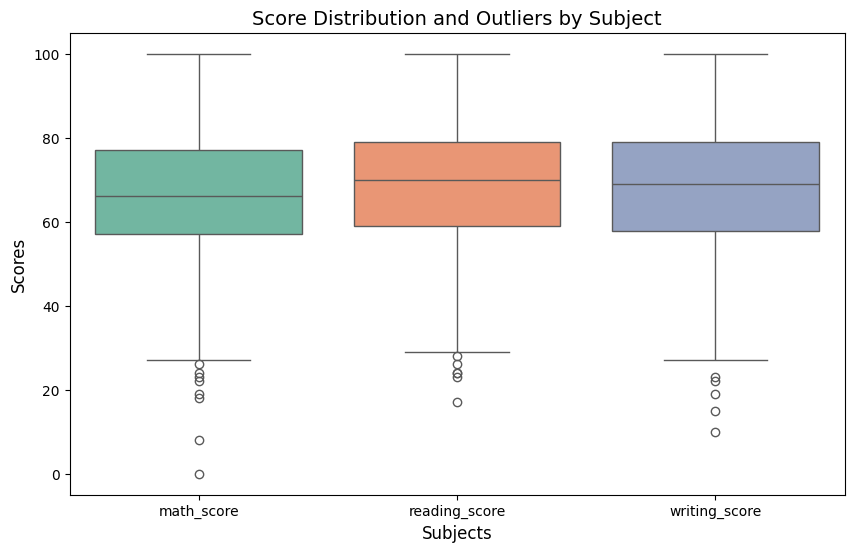

In [42]:
# Check outliers in math_score using boxplot

plt.figure(figsize=(10 , 6))
sns.boxplot(data=df[['math_score', 'reading_score', 'writing_score']], palette='Set2')
plt.title('Score Distribution and Outliers by Subject', fontsize=14)
plt.ylabel('Scores', fontsize=12)
plt.xlabel('Subjects', fontsize=12)

plt.show()

C:\Users\mosta\AppData\Local\Temp\ipykernel_28000\1772230490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parental_level_of_education', y='average_score', data=df, order=parental_level_of_education, palette='viridis')


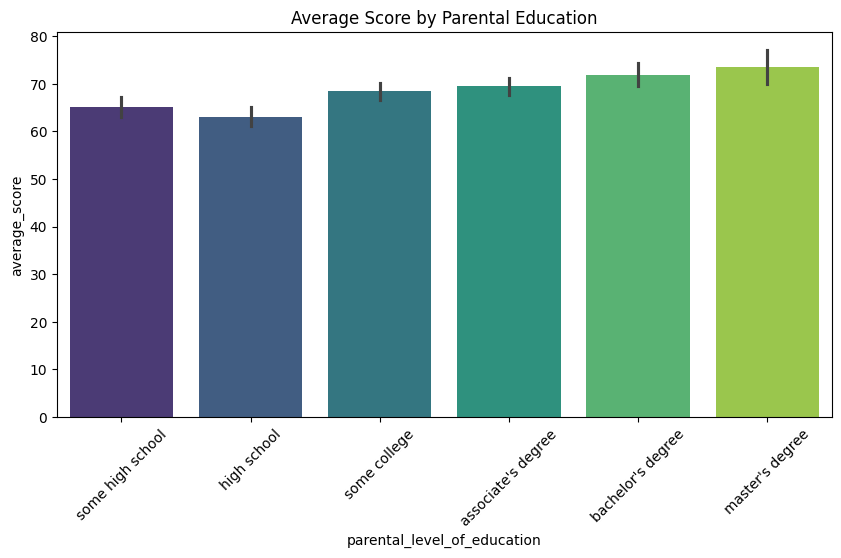

In [43]:
#=========Some Relationships========================

plt.figure(figsize=(10, 5))

parental_level_of_education = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
sns.barplot(x='parental_level_of_education', y='average_score', data=df, order=parental_level_of_education, palette='viridis')
plt.xticks(rotation=45) 
plt.title('Average Score by Parental Education')
plt.show()

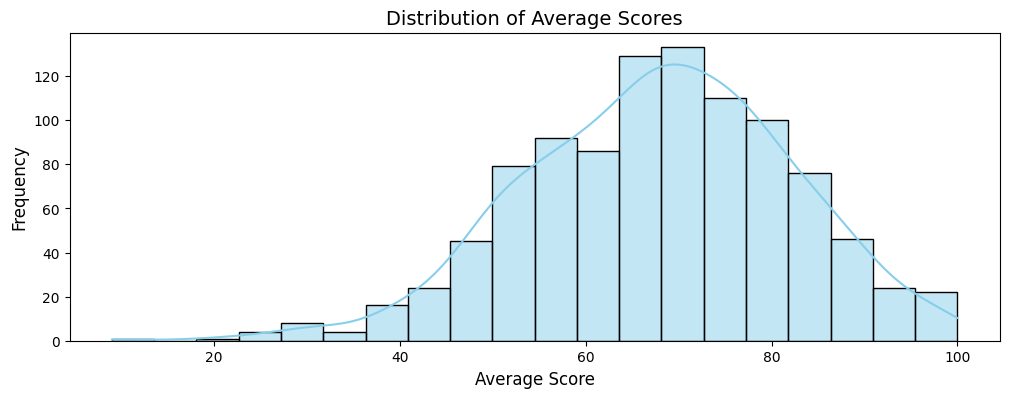

In [44]:
plt.figure(figsize=(12, 4))
sns.histplot(data=df, x='average_score', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Average Scores', fontsize=14)
plt.xlabel('Average Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()